# GMM Tuning

| | |
|---|---|
| **Algorithm** | GaussianMixture |
| **Dataset** | Iris (150 samples, 4 features) |
| **Task** | Clustering (비지도 학습) |
| **Metric** | Silhouette Score, Davies-Bouldin Index, BIC, AIC |

## 튜닝 포인트

| # | 튜닝 | 내용 | 기대 효과 |
|---|---|---|---|
| 1 | **Feature Scaling** | StandardScaler 적용 | 스케일 차이가 공분산 추정 왜곡 방지 |
| 2 | **covariance_type 비교** | full / tied / diag / spherical | 공분산 가정에 따른 유연성 vs 파라미터 수 트레이드오프 |
| 3 | **BIC/AIC로 n_components 탐색** | 1~10 범위 탐색 | 과적합 없이 최적 클러스터 수 선택 |

## Imports
---

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

## Data Loading
---
- `iris.csv`: 150 samples, 4 features
- 비지도 학습 → Id, Species 제외

In [26]:
df = pd.read_csv('../datasets/iris.csv')
X = df.drop(columns=['Id', 'Species']).values
print(f'Shape: {X.shape}')
df.head()

Shape: (150, 4)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Base Model
---
- GaussianMixture(n_components=3, covariance_type='full'), 스케일링 없음

In [27]:
base_model = GaussianMixture(n_components=3, random_state=42)
base_labels = base_model.fit_predict(X)
base_sil = silhouette_score(X, base_labels)
base_dbi = davies_bouldin_score(X, base_labels)
print(f'Base — Silhouette: {base_sil:.4f}, Davies-Bouldin: {base_dbi:.4f}')
print(f'Base — BIC: {base_model.bic(X):.2f}, AIC: {base_model.aic(X):.2f}')

Base — Silhouette: 0.5009, Davies-Bouldin: 0.7487
Base — BIC: 582.48, AIC: 450.02


## Tuning 1: Feature Scaling
---
- GMM은 각 클러스터를 다변량 정규분포로 모델링한다
- 공분산 행렬(Σ) 추정 시 스케일이 큰 피처가 분산을 지배 → 잘못된 클러스터 형태 학습
- StandardScaler로 각 피처가 공분산에 균등하게 기여하도록 조정

In [28]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

sc_model = GaussianMixture(n_components=3, random_state=42)
sc_labels = sc_model.fit_predict(X_sc)
sc_sil = silhouette_score(X_sc, sc_labels)
sc_dbi = davies_bouldin_score(X_sc, sc_labels)
print(f'Scaled — Silhouette: {sc_sil:.4f}, Davies-Bouldin: {sc_dbi:.4f}')
print(f'Scaled — BIC: {sc_model.bic(X_sc):.2f}, AIC: {sc_model.aic(X_sc):.2f}')

Scaled — Silhouette: 0.4092, Davies-Bouldin: 0.8669
Scaled — BIC: 848.40, AIC: 715.93


## Tuning 2: covariance_type 비교
---

| covariance_type | 가정 | 파라미터 수 | 특징 |
|---|---|---|---|
| `full` | 각 클러스터 독립적인 공분산 행렬 | 가장 많음 | 가장 유연, 과적합 위험 |
| `tied` | 모든 클러스터 동일한 공분산 공유 | 중간 | 클러스터 모양이 같다고 가정 |
| `diag` | 피처 간 독립 가정 (대각만) | 적음 | Naive Bayes와 유사 |
| `spherical` | 구형 가정 (분산만, 방향 없음) | 가장 적음 | K-Means와 가장 유사 |

- 파라미터 수가 적을수록 단순 → 데이터가 가정을 따를 때 더 강건

In [29]:
cov_types = ['full', 'tied', 'diag', 'spherical']
cov_results = []

for cov in cov_types:
    m = GaussianMixture(n_components=3, covariance_type=cov, random_state=42)
    labels = m.fit_predict(X_sc)
    sil = silhouette_score(X_sc, labels)
    dbi = davies_bouldin_score(X_sc, labels)
    bic = m.bic(X_sc)
    aic = m.aic(X_sc)
    cov_results.append({'covariance_type': cov, 'Silhouette': sil, 'Davies-Bouldin': dbi, 'BIC': bic, 'AIC': aic})
    print(f'{cov:12s}  Silhouette: {sil:.4f}  D-B: {dbi:.4f}  BIC: {bic:.1f}  AIC: {aic:.1f}')

df_cov = pd.DataFrame(cov_results)

full          Silhouette: 0.4092  D-B: 0.8669  BIC: 848.4  AIC: 715.9
tied          Silhouette: 0.4719  D-B: 0.6799  BIC: 931.3  AIC: 859.1
diag          Silhouette: 0.3919  D-B: 0.7229  BIC: 1036.7  AIC: 958.4
spherical     Silhouette: 0.4669  D-B: 0.6506  BIC: 1243.0  AIC: 1191.8


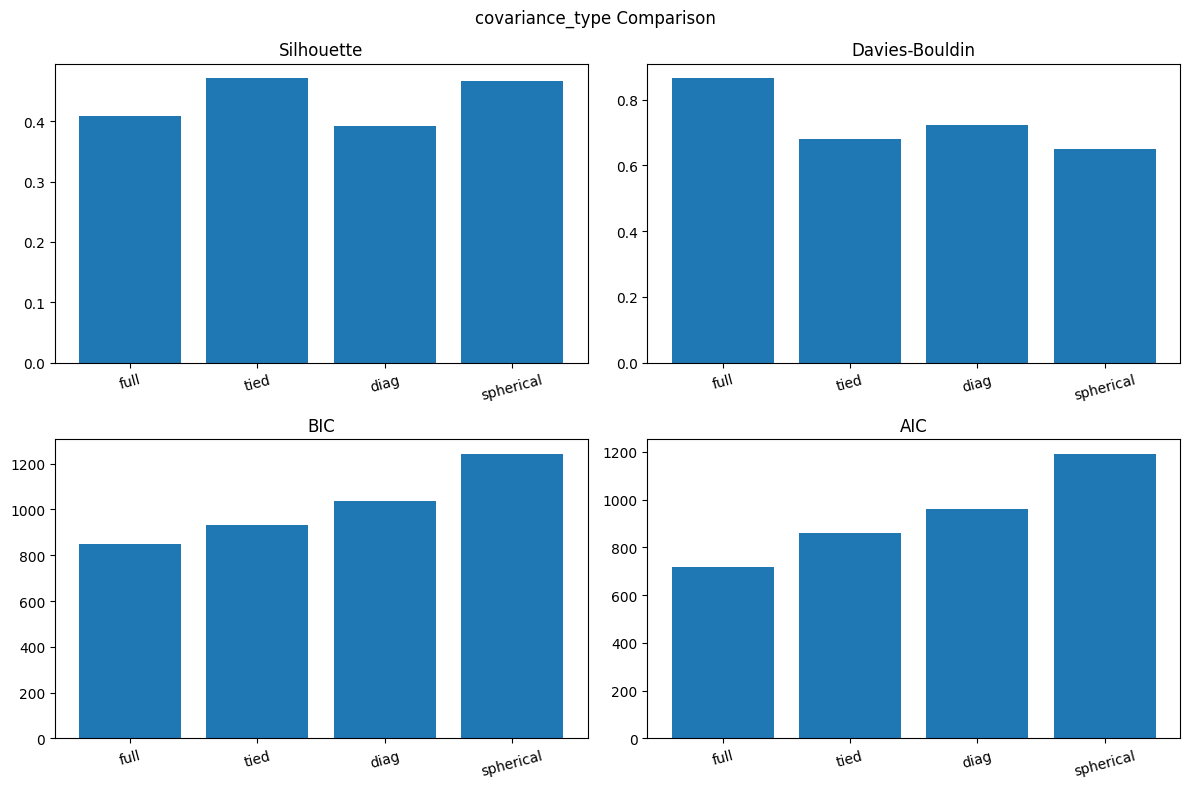

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, ['Silhouette', 'Davies-Bouldin', 'BIC', 'AIC']):
    ax.bar(df_cov['covariance_type'], df_cov[col])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('covariance_type Comparison')
plt.tight_layout()
plt.show()

## Tuning 3: BIC / AIC로 최적 n_components 탐색
---
- `BIC = -2*log(L) + k*log(n)` — n이 클수록 패널티 ↑, 더 단순한 모델 선호
- `AIC = -2*log(L) + 2*k` — BIC보다 복잡한 모델 허용
- L: 데이터 우도, k: 파라미터 수, n: 샘플 수
- BIC/AIC **최소** 지점 = 과적합 없이 데이터를 가장 잘 설명하는 컴포넌트 수

Best covariance_type by BIC: full


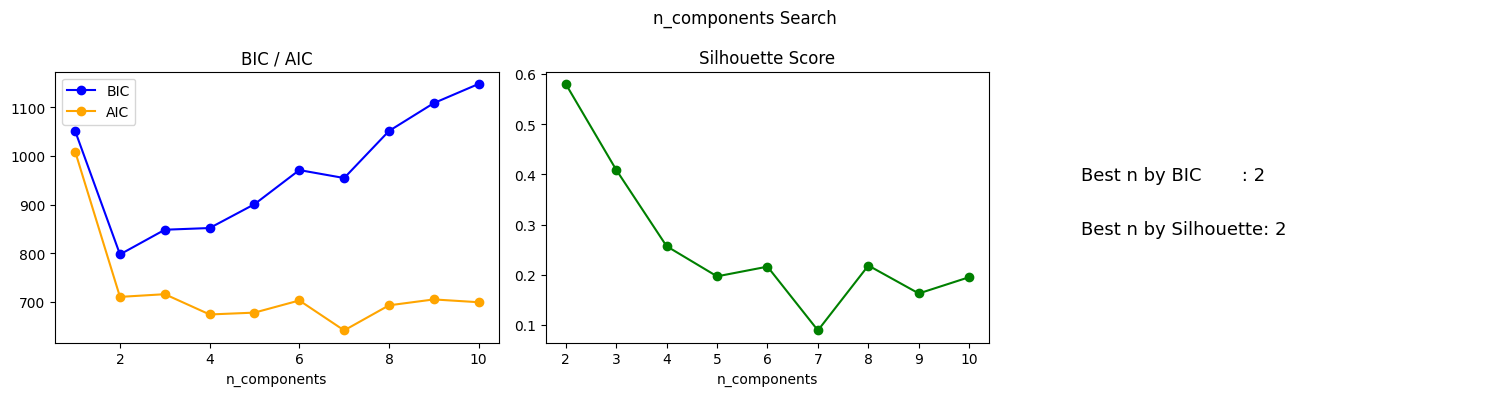

In [31]:
best_cov = df_cov.loc[df_cov['BIC'].idxmin(), 'covariance_type']
print(f'Best covariance_type by BIC: {best_cov}')

n_range = range(1, 11)
bics, aics, sils = [], [], []

for n in n_range:
    m = GaussianMixture(n_components=n, covariance_type=best_cov, random_state=42)
    m.fit(X_sc)
    labels = m.predict(X_sc)
    bics.append(m.bic(X_sc))
    aics.append(m.aic(X_sc))
    sils.append(silhouette_score(X_sc, labels) if n >= 2 else None)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(n_range, bics, marker='o', color='blue',   label='BIC')
axes[0].plot(n_range, aics, marker='o', color='orange', label='AIC')
axes[0].set_xlabel('n_components')
axes[0].set_title('BIC / AIC')
axes[0].legend()
sil_vals = [s for s in sils if s is not None]
sil_ns   = [n for n, s in zip(n_range, sils) if s is not None]
axes[1].plot(sil_ns, sil_vals, marker='o', color='green')
axes[1].set_xlabel('n_components')
axes[1].set_title('Silhouette Score')
axes[2].axis('off')
best_n_bic = list(n_range)[bics.index(min(bics))]
best_n_sil = sil_ns[sil_vals.index(max(sil_vals))]
axes[2].text(0.1, 0.6, f'Best n by BIC       : {best_n_bic}', fontsize=13)
axes[2].text(0.1, 0.4, f'Best n by Silhouette: {best_n_sil}', fontsize=13)
plt.suptitle('n_components Search')
plt.tight_layout()
plt.show()

## Results
---
- Base / Scaled / Best (BIC 기준 최적 cov + n_components) 비교

                  Model  Silhouette  Davies-Bouldin
Base (no scaling, full)    0.500947        0.748729
          Scaled (full)    0.409184        0.866857
   Best (cov=full, k=2)    0.580184        0.597555


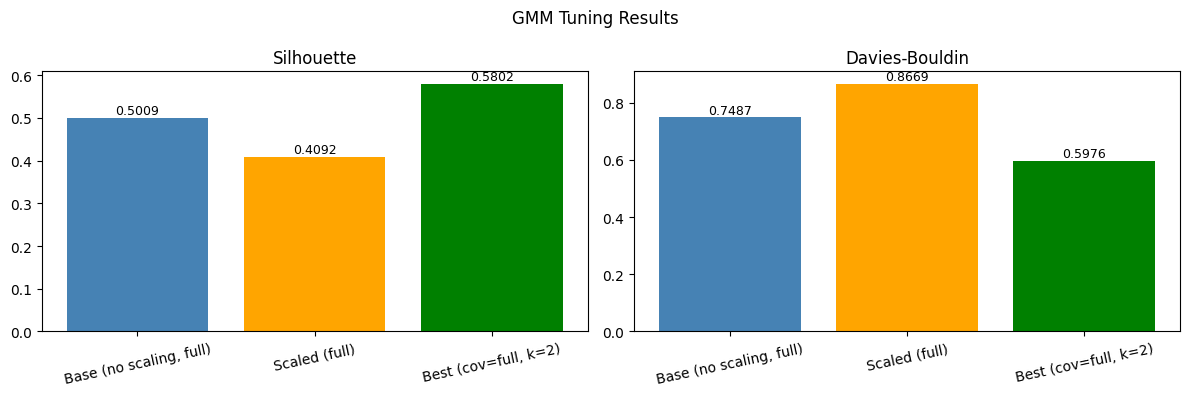

In [32]:
best_model = GaussianMixture(n_components=best_n_bic, covariance_type=best_cov, random_state=42)
best_labels = best_model.fit_predict(X_sc)
best_sil = silhouette_score(X_sc, best_labels)
best_dbi = davies_bouldin_score(X_sc, best_labels)

result_table = pd.DataFrame({
    'Model':          ['Base (no scaling, full)', 'Scaled (full)', f'Best (cov={best_cov}, k={best_n_bic})'],
    'Silhouette':     [base_sil, sc_sil, best_sil],
    'Davies-Bouldin': [base_dbi, sc_dbi, best_dbi]
})
print(result_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['Silhouette', 'Davies-Bouldin']):
    bars = ax.bar(result_table['Model'], result_table[col], color=['steelblue', 'orange', 'green'])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=12)
    for bar, val in zip(bars, result_table[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('GMM Tuning Results')
plt.tight_layout()
plt.show()